# Tesla Deliveries End-to-End ML Pipeline
This notebook implements an end-to-end Machine Learning pipeline on the Tesla deliveries dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


## 1. Data Preprocessing

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f"Dataset shape: {df.shape}")
missing = df.isnull().sum()
if missing.sum() > 0:
    df = df.dropna()
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df.head()


Dataset shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


## 2. Exploratory Data Analysis (EDA)

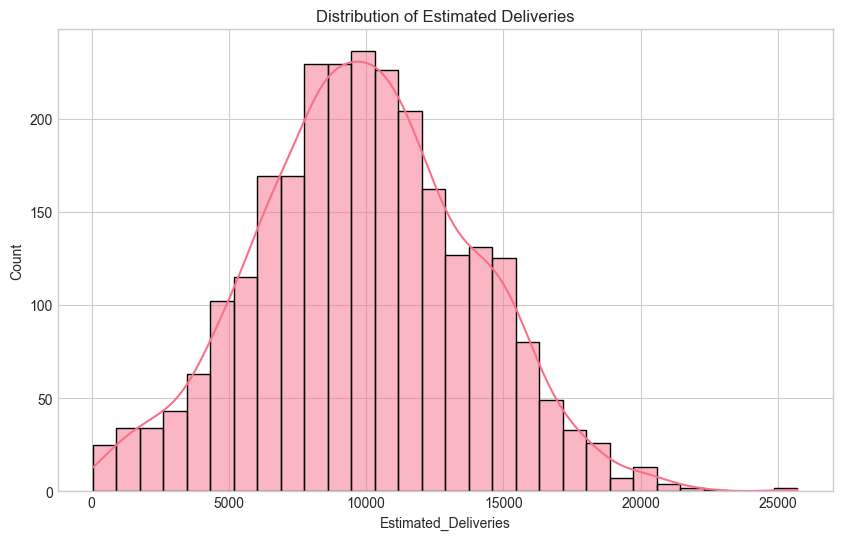

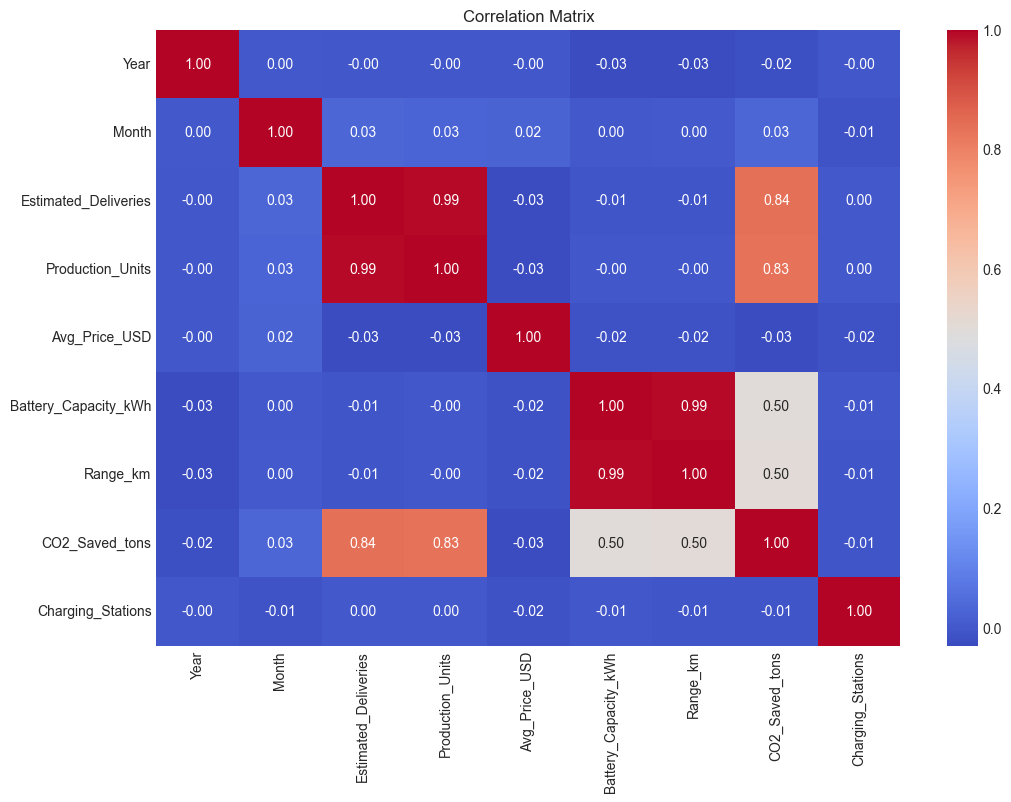

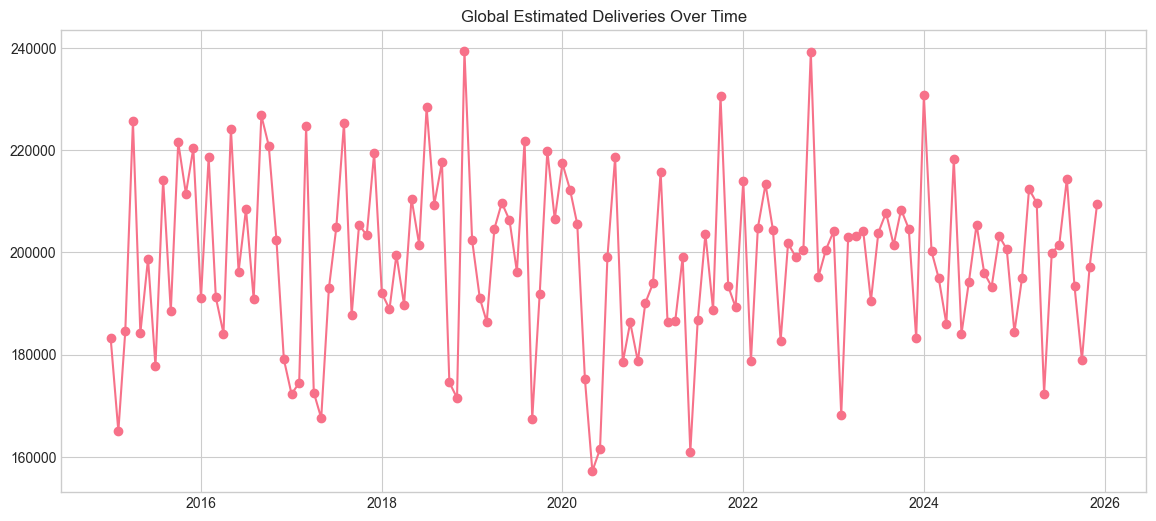

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated_Deliveries'], kde=True, bins=30)
plt.title('Distribution of Estimated Deliveries')
plt.show()

plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

monthly_deliveries = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(monthly_deliveries['Date'], monthly_deliveries['Estimated_Deliveries'], marker='o')
plt.title('Global Estimated Deliveries Over Time')
plt.grid(True)
plt.show()


## 3 & 4. Feature Engineering and Regression Modeling
Predicting `Estimated_Deliveries` based on features like `Avg_Price_USD`, `Battery_Capacity_kWh`, `Region`, `Model`, etc. We use a Random Forest model here.

Starting Grid Search...
Best Parameters: {'regressor__max_depth': 10, 'regressor__n_estimators': 100}
RMSE: 3878.50, R2: -0.0092


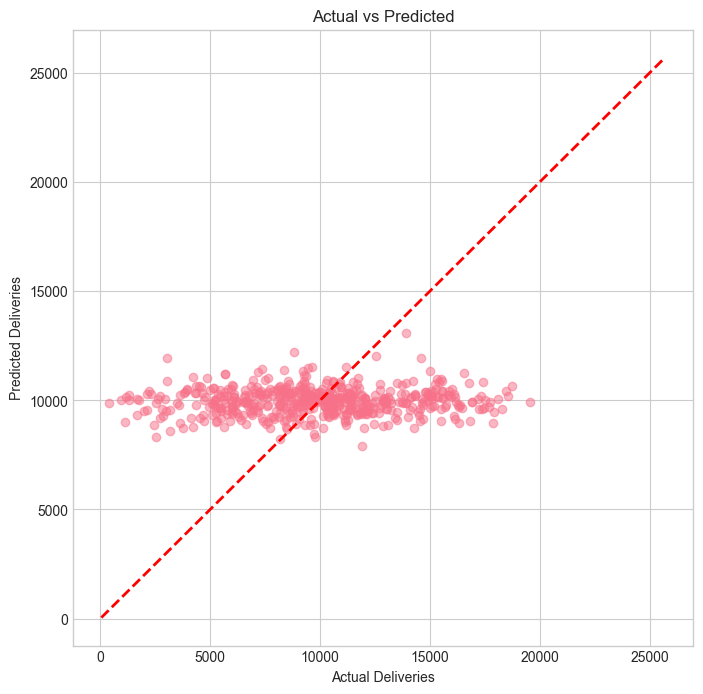

In [4]:
target = 'Estimated_Deliveries'
features = ['Year', 'Month', 'Region', 'Model', 'Avg_Price_USD', 
            'Battery_Capacity_kWh', 'Range_km', 'Source_Type', 'Charging_Stations']

X = df[features]
y = df[target]

categorical_features = ['Region', 'Model', 'Source_Type']
numeric_features = ['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [None, 10, 20]
}

print("Starting Grid Search...")
grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}, R2: {r2:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted')
plt.show()


## 5. Time Series Forecasting (SARIMA)
Forecasting global aggregated deliveries over time.

Forecast RMSE (last 12 months): 20683.91


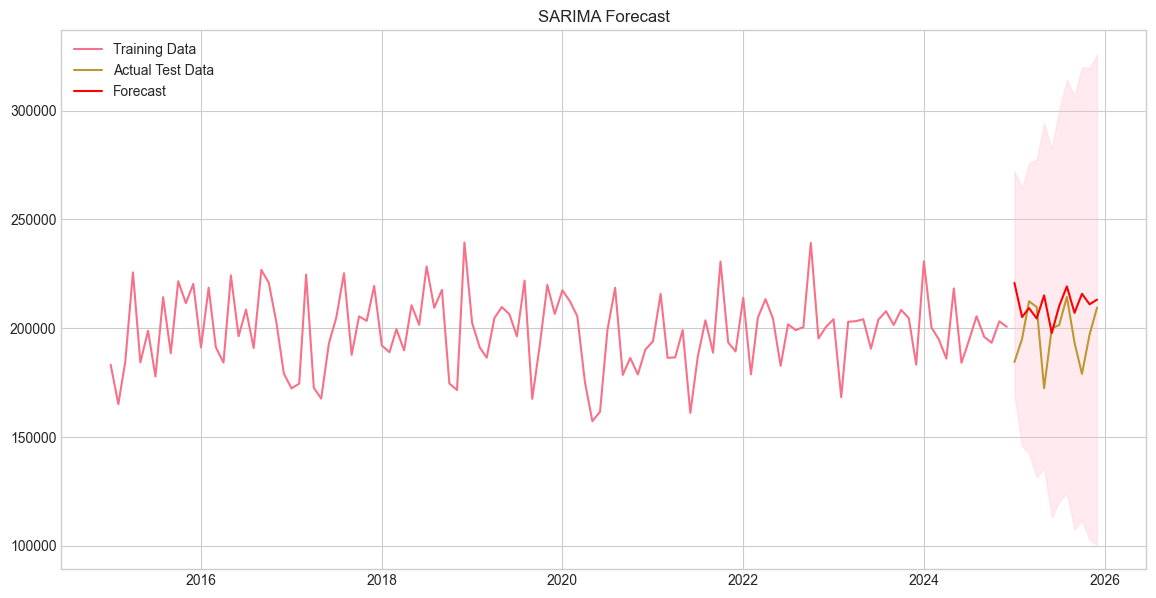

In [5]:
monthly_data = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
monthly_data.set_index('Date', inplace=True)
monthly_data = monthly_data.asfreq('MS')

train = monthly_data.iloc[:-12]
test = monthly_data.iloc[-12:]

model = SARIMAX(train['Estimated_Deliveries'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit(disp=False)

forecast = results.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

rmse = np.sqrt(mean_squared_error(test['Estimated_Deliveries'], forecast_mean))
print(f"Forecast RMSE (last 12 months): {rmse:.2f}")

plt.figure(figsize=(14, 7))
plt.plot(train.index, train['Estimated_Deliveries'], label='Training Data')
plt.plot(test.index, test['Estimated_Deliveries'], label='Actual Test Data')
plt.plot(forecast_mean.index, forecast_mean, color='red', label='Forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Forecast')
plt.legend()
plt.show()
